In [228]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

import os

import sys

sys.path.append('../mcap')


In [229]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from matplotlib.dates import date2num, num2date
from matplotlib.colors import ListedColormap
from matplotlib import dates as mdates
from matplotlib.patches import Patch
from matplotlib import pyplot as plt
from matplotlib import ticker

import datetime
# Plot Tong's default setting
SMALL_SIZE  = 18
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE, family='sans-serif', serif='Open Sans')#'Arial') # controls default text sizes

plt.rc('axes',   titlesize=BIGGER_SIZE)    # fontsize of the axes title
plt.rc('axes',   labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick',  labelsize=SMALL_SIZE)    # fontsize of the tick labels"
plt.rc('ytick',  labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('text')


In [230]:
from scipy.stats import chi2 as qchisq

from scipy import linalg
from math import ceil
import numpy as np

from loess_1d import loess_1d

def fit_wls(x, y, w):
    X = np.column_stack([np.ones_like(x), -(x**2), x])

    # weighted least squares
    sw = w
    Xw = X * sw[:, None]
    yw = y * sw

    coef, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
    c, a, b  = map(float, coef)

    # residual based variance estimate
    yhat  = X @ coef
    resid = (y - yhat) * sw
    df    = int(np.sum(w > 0) - X.shape[1])
    s2    = float(np.sum(resid**2) / df)

    XtWX     = Xw.T @ Xw
    cov_full = s2 * np.linalg.inv(XtWX)

    vc_ab = cov_full[1:3, 1:3]
    return a, b, c, vc_ab

def mcap_loglikelihood(loglik_profile_values, param_search, confidence=0.95, span=0.75, n_grid=1000):
    df_data       = pd.DataFrame(columns=["lp", "b", "a"])
    df_data["b"]  = param_search
    df_data["a"]  = param_search**2

    param_grid = np.linspace(min(param_search), max(param_search), n_grid)

    loglik_values = loglik_profile_values[np.argsort(param_search)]
    param_search  = param_search[np.argsort(param_search)]

    df_data["lp"] = loglik_values

    _, loglik_sm, _ = loess_1d(x=param_search, y=loglik_values,
                                        xnew=param_grid,
                                        degree=2, frac=span)

    arg_max   = np.argmax(loglik_sm)
    p_mle_sm  = param_grid[arg_max]

    disttance = abs(param_search - p_mle_sm)
    max_dist  = np.max(disttance)

    weights = np.full(len(param_search), np.nan)
    weights = (1-(disttance/max_dist)**3)**3
    weights = {param_search[idx_p]: weights[idx_p] for idx_p in range(weights.shape[0])}

    df_data["weights"] = df_data["b"].replace(weights)

    a, b, c, cov = fit_wls(df_data["b"].values, df_data["lp"].values, df_data["weights"].values)
    var_a  = cov[0, 0]
    var_b  = cov[1, 1]
    cov_ab = cov[0, 1]

    se_mc_squared    = (1 / (4 * a**2)) * (var_b - (2 * b/a) * cov_ab + (b**2 / a**2) * var_a)
    se_stat_squared  = 1/(2*a)
    se_total_squared = se_mc_squared + se_stat_squared
    loglik_diff      = min(loglik_sm) -  loglik_sm

    delta            = qchisq.ppf(confidence, 1) * (a * se_mc_squared + 0.5)

    ci = param_grid[loglik_sm > (max(loglik_sm) - delta)][[0, -1]]

    if ci.shape[0]>0:
        ci_low           = ci[0]
        ci_high          = ci[-1]
    else:
        ci_low           = None
        ci_high          = None

    confidence = int(confidence*100)
    param_mle_df               = pd.DataFrame(columns=["mle", "delta", f"{confidence}_high", f"{confidence}_low"])
    param_mle_df["mle"]        = [param_grid[arg_max]]
    param_mle_df["se_stat"]    = [se_stat_squared]
    param_mle_df["se_mc"]      = [se_mc_squared]
    param_mle_df[f"{confidence}_low"]  = [ci_low]
    param_mle_df[f"{confidence}_high"] = [ci_high]

    fit_df                  = pd.DataFrame(columns=["parameter", "loglik_smooth", "quadratic"])
    fit_df["parameter"]     = param_grid
    fit_df["loglik_smooth"] = loglik_sm
    fit_df["quadratic"]     = a *(-(param_grid**2)) + b * param_grid + c

    return fit_df, param_mle_df

In [231]:
param_name = "bEP"

ll_df = pd.read_csv("data/results.csv")
ll_df = ll_df[ll_df["loglik.se"]<2]
ll_df.sort_values(by="ll_lowIQ", ascending=False, inplace=True)
mle_pars = ll_df.iloc[0]

ll_all_df = ll_df.copy()
ll_all_df = ll_all_df.sort_values(by=param_name)
ll_all_df = ll_all_df[ll_all_df[param_name].between(-0.8, 1)]
ll_all_df = ll_all_df[ll_all_df["loglik.se"]<2]

delta_mle = 50
ll_all_df  = ll_all_df[ll_all_df["loglik"] > (mle_pars["loglik"] - delta_mle)]

pmin, pmax = ll_all_df[param_name].min(), ll_all_df[param_name].max()
delta_bEP  = 0.1

i = 0
ll_samp_df = []
while pmin + ((delta_bEP)*(i+1)) <= pmax:
    x_search = [pmin+delta_bEP*i, pmin+((delta_bEP)*(i+1))]
    ll_r_df = ll_df[ll_df[param_name]     >= x_search[0]]  # Filter rows where bEP is greater than or equal to the lower bound
    ll_r_df = ll_r_df[ll_r_df[param_name] < x_search[1]]  # Filter rows where bEP is less than the upper bound
    i += 1
    if len(ll_r_df)>0:
        ll_r_df = ll_r_df.sort_values(by="loglik").iloc[0]
        ll_samp_df.append(ll_r_df[[param_name, "loglik", "loglik.se"]])
ll_samp_df = pd.concat(ll_samp_df, axis=1).T


In [232]:
from pypomp import mcap

param_name = "bCP"

ll_all_df = ll_df.copy()
ll_all_df = ll_all_df.sort_values(by=param_name)
ll_all_df = ll_all_df[ll_all_df["loglik.se"]<2]

delta_mle = 50
ll_all_df = ll_all_df[ll_all_df["loglik"] > (mle_pars["loglik"] - delta_mle)]

ll_sm_df  = ll_all_df.copy()
param_arr = ll_sm_df[param_name].values
ll_arr    = ll_sm_df["loglik"].values

loglik_values = ll_arr[np.argsort(param_arr)]
param_search  = param_arr[np.argsort(param_arr)]

mcap_out = mcap(param_arr, ll_arr, level=0.95, span=0.75, n_grid=1000)


(-2191.170536871609, -2129.01293993997)

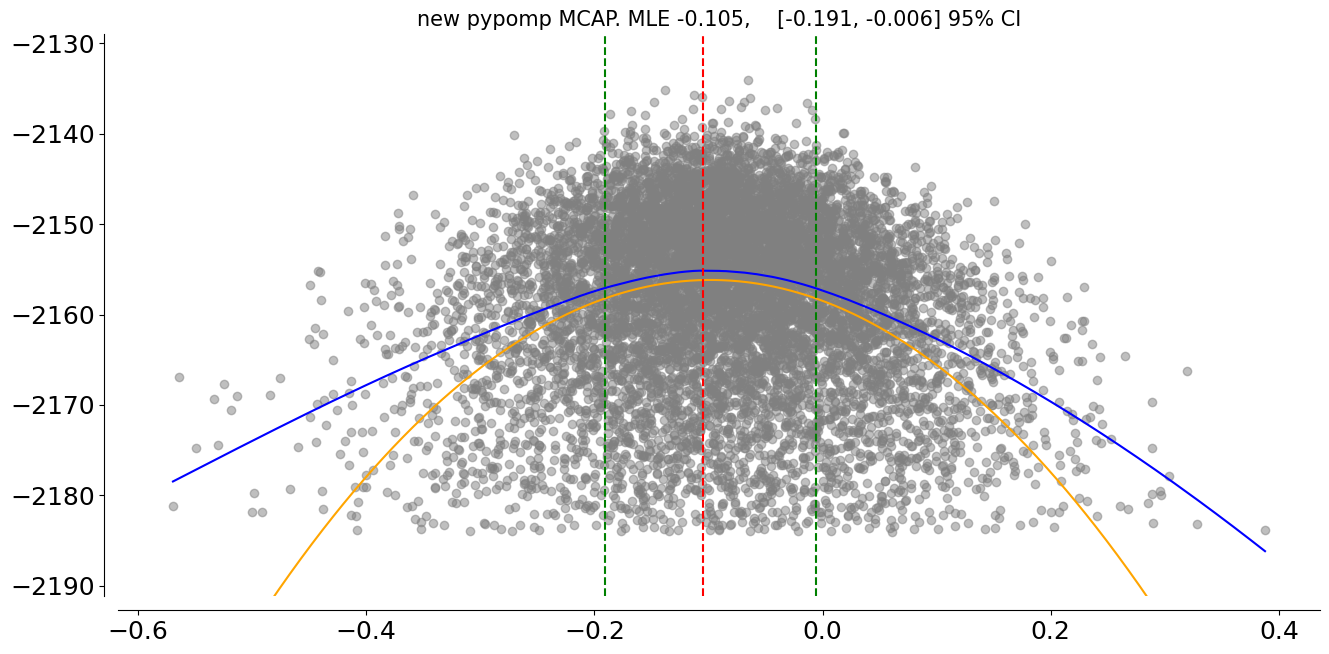

In [233]:

mcap_df            = pd.DataFrame(mcap_out.fit)
mcap_df["mle"]     = mcap_out.mle
mcap_df["ci_low"]  = mcap_out.ci[0]
mcap_df["ci_high"] = mcap_out.ci[1]

fig, ax = plt.subplots(1, 1, figsize=(15.5, 7.3))

ax.plot(mcap_df["parameter"], mcap_df["smoothed"], color="blue", label="Smoothed loglikelihood")
ax.plot(mcap_df["parameter"], mcap_df["quadratic"], color="orange", label="Quadratic fit")

ax.scatter(ll_sm_df[param_name], ll_sm_df.loglik, color="gray", alpha=0.5, label="Data points")

ax.axvline(x=mcap_df.mle[0],     color="red", linestyle="--", label="MLE")
ax.axvline(x=mcap_df.ci_low[0],  color="green", linestyle="--", label="95% CI low")
ax.axvline(x=mcap_df.ci_high[0], color="green", linestyle="--", label="95% CI high")

ax.set_title("new pypomp MCAP. MLE {:0.3f},    [{:0.3f}, {:0.3f}] 95% CI".format(mcap_df.mle[0],
                                                mcap_df.ci_low[0],
                                                mcap_df.ci_high[0]), fontsize=15)
ax.spines["bottom"].set_position(('outward', 10)) # outward by 50 points
ax.spines["left"].set_position(('outward', 10))   # outward by 10 points
ax.spines[['right', 'top']].set_visible(False)

ax.set_ylim([min(mcap_df.smoothed)-5, max(ll_sm_df.loglik)+5])


In [234]:
p_df, ci_df = mcap_loglikelihood(ll_arr, param_arr, confidence=0.95, span=0.75, n_grid=1000)


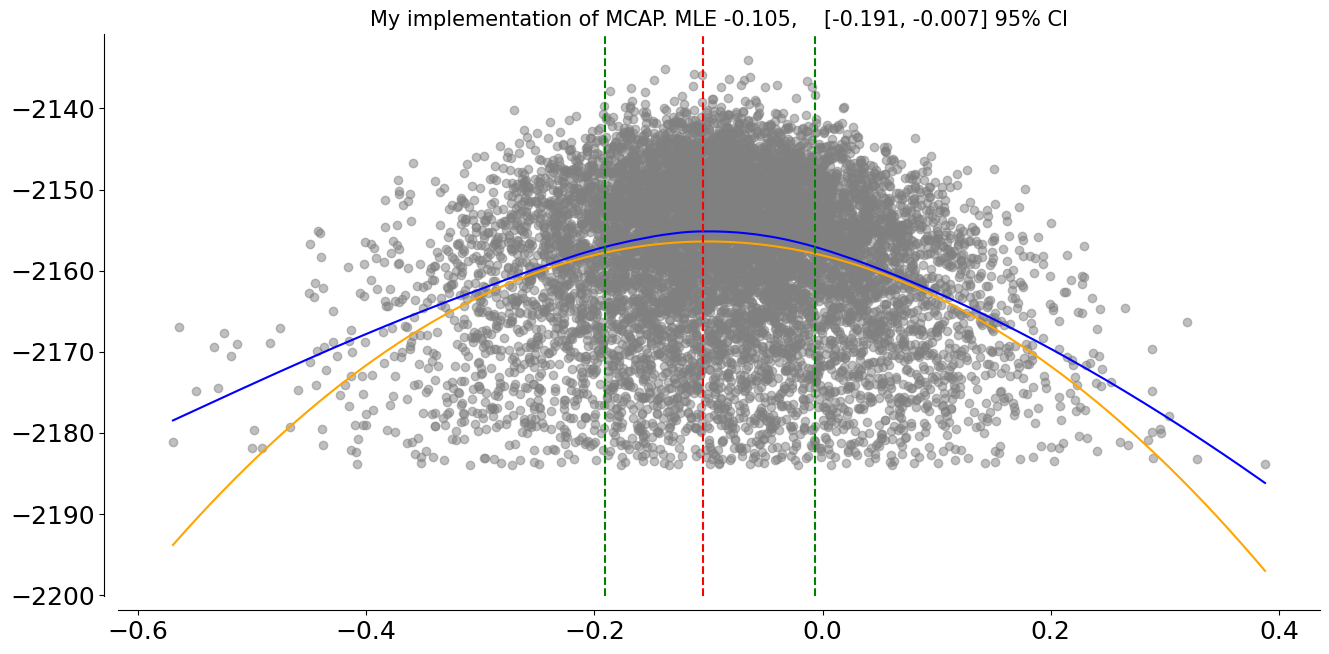

In [235]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(15.5, 7.3))

ax.plot(p_df["parameter"], p_df["loglik_smooth"], color="blue", label="Smoothed loglikelihood")
ax.plot(p_df["parameter"], p_df["quadratic"], color="orange", label="Quadratic fit")

ax.scatter(param_arr, ll_arr, color="gray", alpha=0.5)

ax.axvline(x=ci_df.mle[0],        color="red", linestyle="--", label="MLE")
ax.axvline(x=ci_df["95_high"][0], color="green", linestyle="--", label="95% CI low")
ax.axvline(x=ci_df["95_low"][0],  color="green", linestyle="--", label="95% CI high")

ax.set_title("My implementation of MCAP. MLE {:0.3f},    [{:0.3f}, {:0.3f}] 95% CI".format(ci_df.mle[0],
                                                ci_df['95_low'][0],
                                                ci_df['95_high'][0]), fontsize=15)
ax.spines["bottom"].set_position(('outward', 10)) # outward by 50 points
ax.spines["left"].set_position(('outward', 10))   # outward by 10 points
ax.spines[['right', 'top']].set_visible(False)



/Users/chaosdonkey06/miniconda3/envs/denv_thai/lib/python3.11/site-packages/pypomp/mcap.py:287: RuntimeWarning: invalid value encountered in sqrt
  se_stat=float(np.sqrt(se_stat2)),


Text(0.02, 0.5, 'log-likelihood')

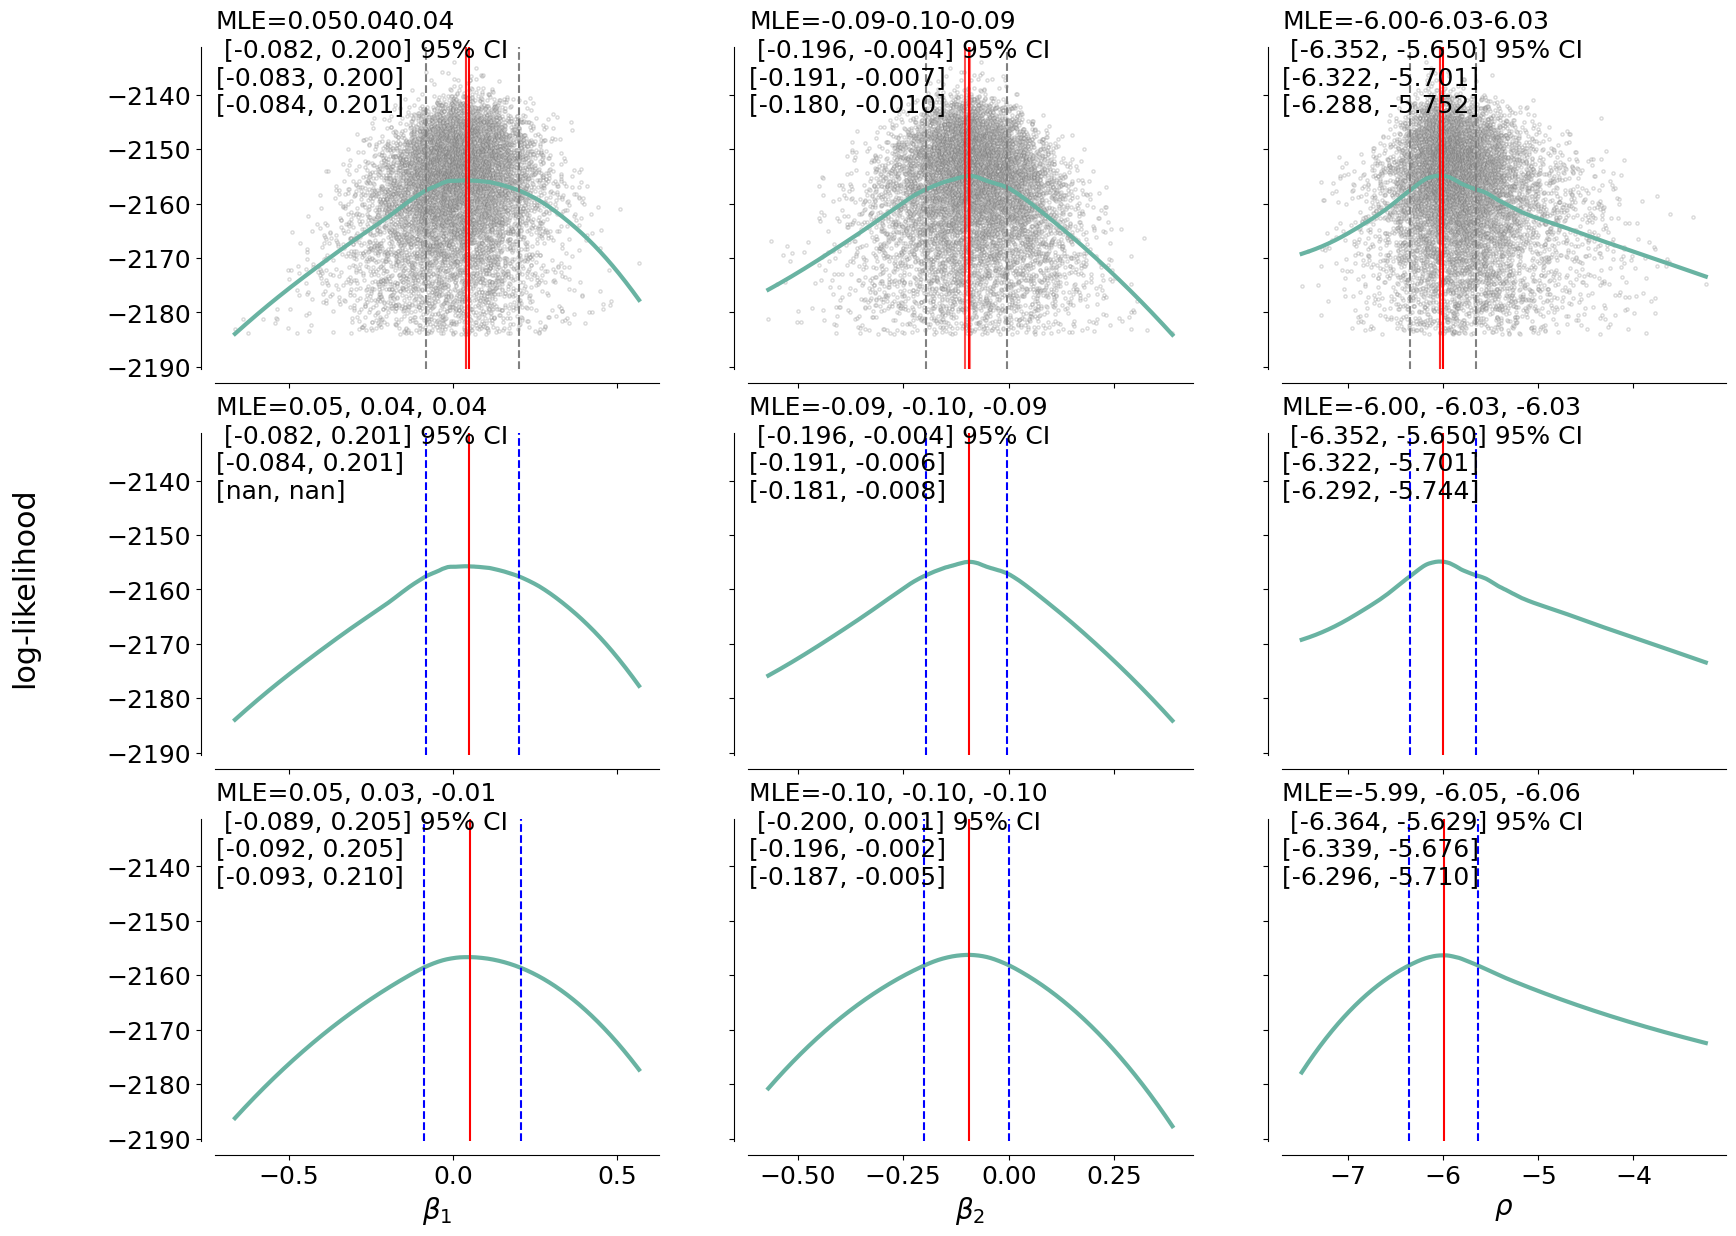

In [244]:
def logit(arr):
    return np.log(arr/(1-arr))

params_name = ["bEP", "bCP", "rho_trans"]

fig, ax = plt.subplots(3, 3, figsize=(19.5, 14.2), sharey=True, sharex="col")
for i_p, param_name in enumerate(params_name):

    ll_all_df          = ll_df.copy()
    ll_df["rho_trans"] = logit(ll_df["rho"])

    ll_all_df = ll_all_df.sort_values(by=param_name)
    ll_all_df = ll_all_df[ll_all_df["loglik.se"]<2]

    delta_mle = 50
    ll_all_df = ll_all_df[ll_all_df["loglik"] > (mle_pars["loglik"] - delta_mle)]

    ll_sm_df  = ll_all_df.copy()
    param_arr = ll_sm_df[param_name].values
    ll_arr    = ll_sm_df["loglik"].values

    p_df, ci1_df = mcap_loglikelihood(ll_arr[np.argsort(param_arr)],
                                    param_arr[np.argsort(param_arr)],
                                    confidence=0.95, span=0.9, n_grid=1000)
    p_df, ci2_df = mcap_loglikelihood(ll_arr[np.argsort(param_arr)],
                                    param_arr[np.argsort(param_arr)],
                                    confidence=0.95, span=0.75, n_grid=1000)
    p_df, ci3_df = mcap_loglikelihood(ll_arr[np.argsort(param_arr)],
                                    param_arr[np.argsort(param_arr)],
                                    confidence=0.95, span=0.5, n_grid=1000)

    ax[0, i_p].plot(p_df["parameter"], p_df["loglik_smooth"], color="#69b3a2", lw=3, label="Smoothed loglikelihood")

    ax[0, i_p].axvline(x=ci1_df["mle"][0],  color="red",  linestyle="-", label="MLE", alpha=1)
    ax[0, i_p].axvline(x=ci2_df["mle"][0],  color="red",  linestyle="-", label="MLE", alpha=0.7)
    ax[0, i_p].axvline(x=ci3_df["mle"][0],  color="red",  linestyle="-", label="MLE", alpha=0.5)


    ax[0, i_p].axvline(x=ci1_df["95_high"][0], color="gray", linestyle="--", label="95% CI")
    ax[0, i_p].axvline(x=ci1_df["95_low"][0],  color="gray", linestyle="--")

    # - #
    ax[0, i_p].scatter(param_arr[np.argsort(param_arr)], ll_arr[np.argsort(param_arr)],
                    color="gray", alpha=0.3, s=5, fc="w")

    ax[0, i_p].text(0.002, 0.8, "MLE={:0.2f}{:0.2f}{:0.2f}\n [{:0.3f}, {:0.3f}] 95% CI\n[{:0.3f}, {:0.3f}]\n[{:0.3f}, {:0.3f}]".format(ci1_df.mle[0], ci2_df.mle[0], ci3_df.mle[0],
                                                                ci1_df['95_low'][0],
                                                                ci1_df['95_high'][0],
                                                                ci2_df['95_low'][0],
                                                                ci2_df['95_high'][0],
                                                                ci3_df['95_low'][0],
                                                                ci3_df['95_high'][0]),
                                                                transform=ax[0, i_p].transAxes)
    ##########

    mcap_out = mcap(param_arr[np.argsort(param_arr)], ll_arr[np.argsort(param_arr)],
                                                        level=0.95, span=0.9, n_grid=1000)
    mcap1_df = pd.DataFrame(mcap_out.fit)
    ci1_df   = pd.DataFrame.from_dict({"mle": mcap_out.mle, "95_low": mcap_out.ci[0], "95_high": mcap_out.ci[1]}, orient="index").T

    mcap_out = mcap(param_arr[np.argsort(param_arr)], ll_arr[np.argsort(param_arr)],
                                                        level=0.95, span=0.75, n_grid=1000)
    mcap2_df = pd.DataFrame(mcap_out.fit)
    ci2_df   = pd.DataFrame.from_dict({"mle": mcap_out.mle, "95_low": mcap_out.ci[0], "95_high": mcap_out.ci[1]}, orient="index").T

    mcap_out = mcap(param_arr[np.argsort(param_arr)], ll_arr[np.argsort(param_arr)],
                                                        level=0.95, span=0.5, n_grid=1000)
    mcap3_df = pd.DataFrame(mcap_out.fit)
    ci3_df   = pd.DataFrame.from_dict({"mle": mcap_out.mle, "95_low": mcap_out.ci[0], "95_high": mcap_out.ci[1]}, orient="index").T


    ax[1, i_p].plot(p_df["parameter"], p_df["loglik_smooth"], color="#69b3a2", lw=3, label="Smoothed loglikelihood")
    ax[1, i_p].axvline(x=ci1_df["mle"][0],     color="red",  linestyle="-", label="MLE")
    ax[1, i_p].axvline(x=ci1_df["95_high"][0], color="b", linestyle="--", label="95% CI")
    ax[1, i_p].axvline(x=ci1_df["95_low"][0],  color="b", linestyle="--")

    ax[1, i_p].text(0.002, 0.8, "MLE={:0.2f}, {:0.2f}, {:0.2f}\n [{:0.3f}, {:0.3f}] 95% CI\n[{:0.3f}, {:0.3f}]\n[{:0.3f}, {:0.3f}]".format(ci1_df.mle[0], ci2_df.mle[0], ci3_df.mle[0],
                                                                ci1_df['95_low'][0], ci1_df['95_high'][0],
                                                                ci2_df['95_low'][0], ci2_df['95_high'][0],
                                                                ci3_df['95_low'][0], ci3_df['95_high'][0]),
                                                                transform = ax[1, i_p].transAxes)

mcap_r_df = pd.read_csv("data/mcap_r_results.csv")

for i_p, param_name in enumerate(params_name):
    mcap_r_pi1_df = mcap_r_df[mcap_r_df.param_name==param_name].query("span==0.9")
    mcap_r_pi1_df = mcap_r_pi1_df.sort_values(by="parameter")

    mcap_r_pi2_df = mcap_r_df[mcap_r_df.param_name==param_name].query("span==0.75")
    mcap_r_pi2_df = mcap_r_pi2_df.sort_values(by="parameter")

    mcap_r_pi3_df = mcap_r_df[mcap_r_df.param_name==param_name].query("span==0.5")
    mcap_r_pi3_df = mcap_r_pi3_df.sort_values(by="parameter")


    ax[2, i_p].plot(mcap_r_pi1_df["parameter"], mcap_r_pi1_df["smoothed"], color="#69b3a2", lw=3, label="Smoothed loglikelihood")

    ax[2, i_p].axvline(x=mcap_r_pi1_df["mle"].iloc[0],     color="red",  linestyle="-", label="MLE")
    ax[2, i_p].axvline(x=mcap_r_pi1_df["ci_high"].iloc[0], color="b", linestyle="--", label="95% CI")
    ax[2, i_p].axvline(x=mcap_r_pi1_df["ci_low"].iloc[0],  color="b", linestyle="--")

    ax[2, i_p].text(0.002, 0.8, "MLE={:0.2f}, {:0.2f}, {:0.2f}\n [{:0.3f}, {:0.3f}] 95% CI\n[{:.3f}, {:.3f}]\n[{:.3f}, {:.3f}]".format(mcap_r_pi1_df["mle"].iloc[0], mcap_r_pi2_df["mle"].iloc[0], mcap_r_pi3_df["mle"].iloc[0],
                                                mcap_r_pi1_df["ci_low"].iloc[0],
                                                mcap_r_pi1_df["ci_high"].iloc[0],
                                                mcap_r_pi2_df["ci_low"].iloc[0],
                                                mcap_r_pi2_df["ci_high"].iloc[0],
                                                mcap_r_pi3_df["ci_low"].iloc[0],
                                                mcap_r_pi3_df["ci_high"].iloc[0]
                                                ),
                                                transform=ax[2, i_p].transAxes)

for axi in ax.flatten():
    axi.spines["bottom"].set_position(('outward', 10)) # outward by 50 points
    axi.spines["left"].set_position(('outward', 10))   # outward by 10 points
    axi.spines[['right', 'top']].set_visible(False)

ax[-1, 0].set_xlabel(r"$\beta_1$")
ax[-1, 1].set_xlabel(r"$\beta_2$")
ax[-1, 2].set_xlabel(r"$\rho$")

fig.supylabel("log-likelihood")


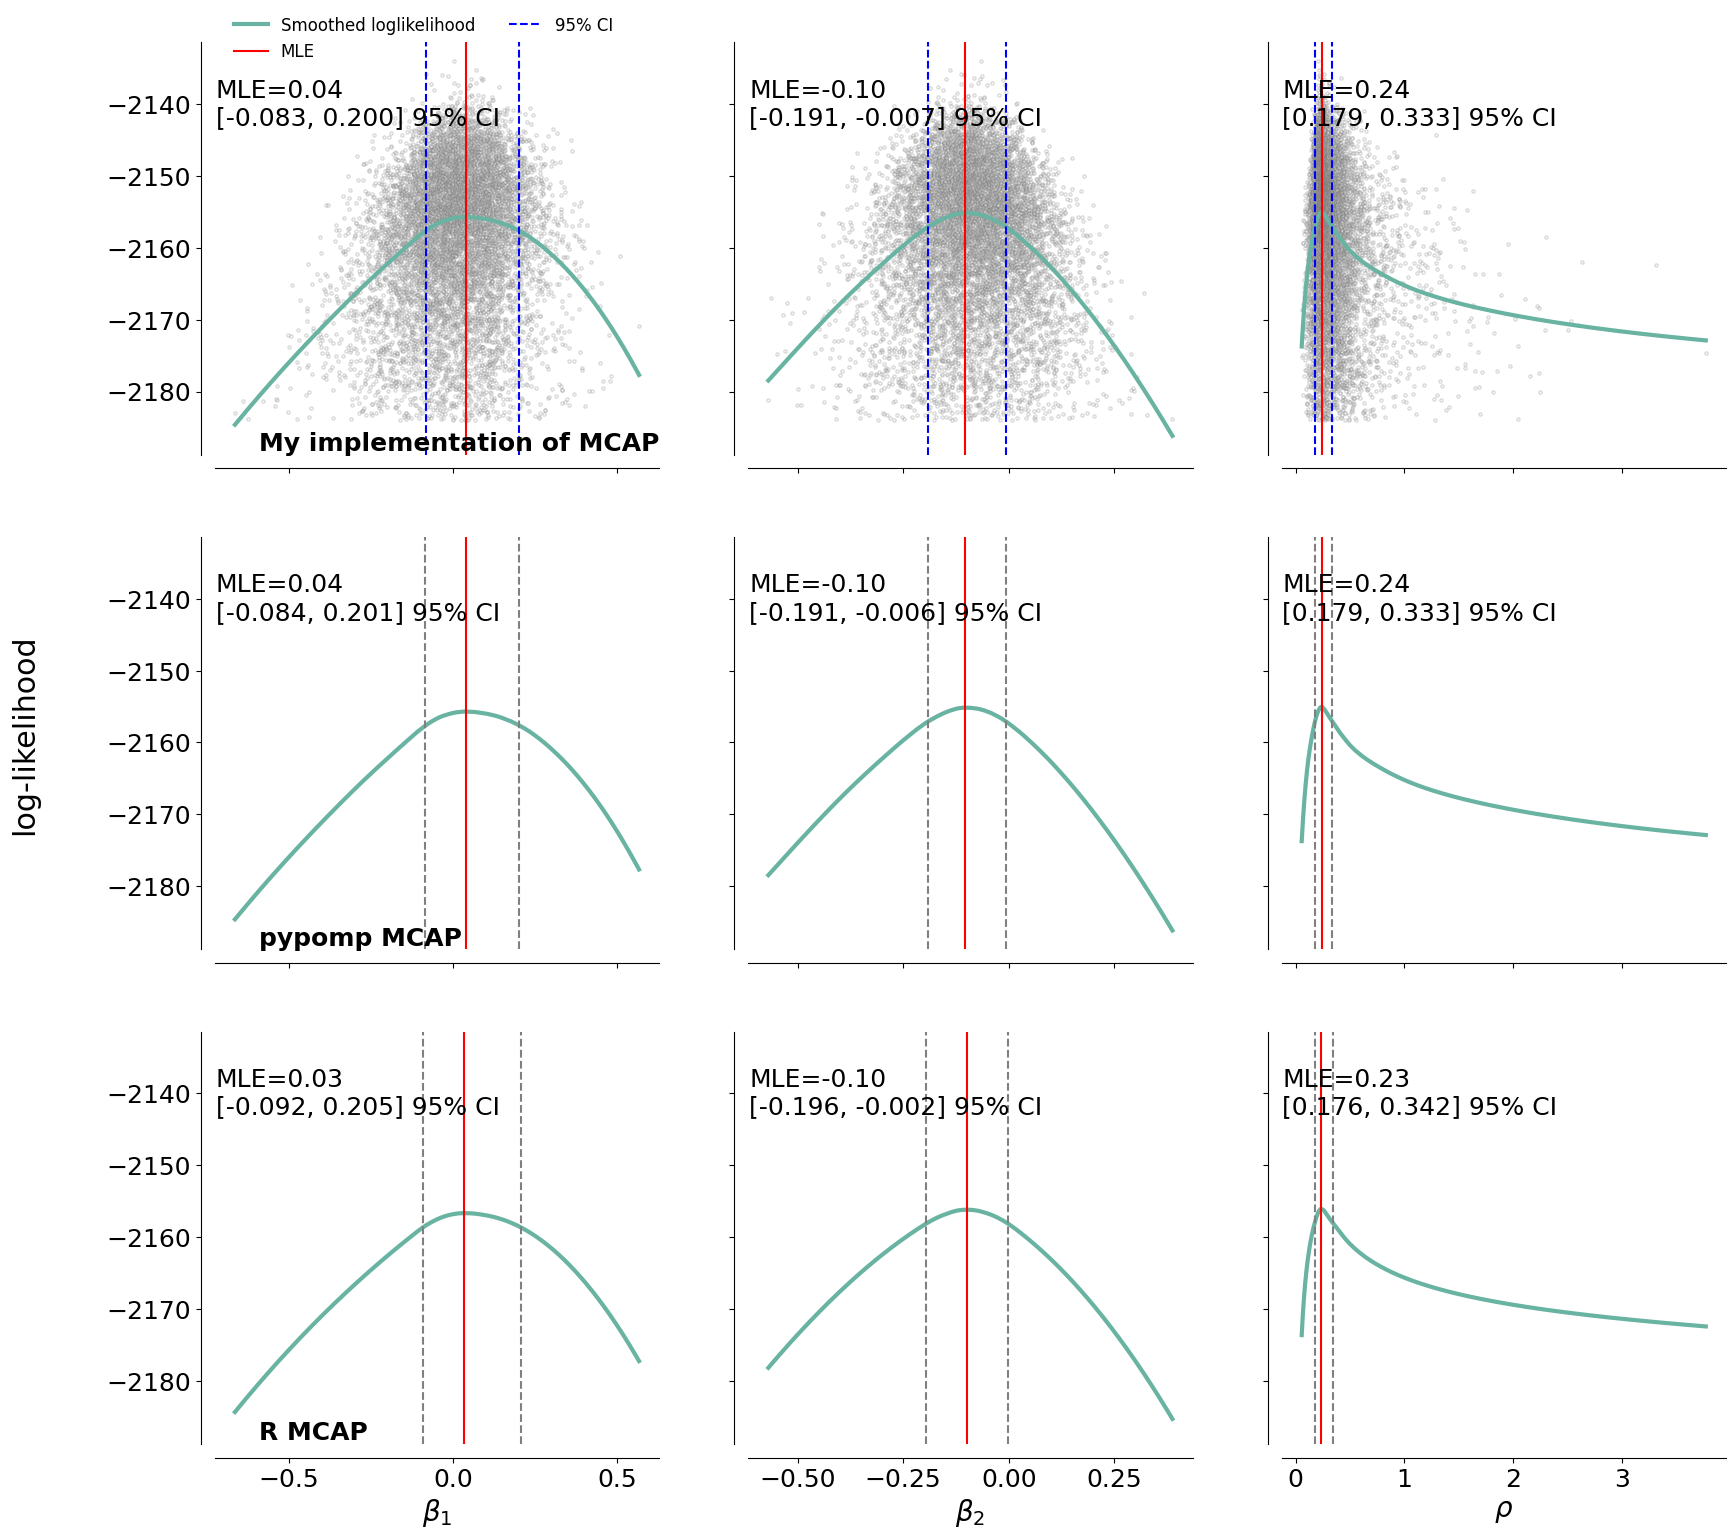

In [ ]:
def logit(arr):
    return np.log(arr/(1-arr))
def expit(arr):
    return 1/(1+np.exp(-arr))

params_name = ["bEP", "bCP", "rho_trans"]

fig, ax = plt.subplots(3, 3, figsize=(19.5, 18.2), sharey=True, sharex="col")


for i_p, param_name in enumerate(params_name):

    ll_all_df          = ll_df.copy()
    ll_df["rho_trans"] = logit(ll_df["rho"])

    ll_all_df = ll_all_df.sort_values(by=param_name)
    ll_all_df = ll_all_df[ll_all_df["loglik.se"]<2]

    delta_mle = 50
    ll_all_df = ll_all_df[ll_all_df["loglik"] > (mle_pars["loglik"] - delta_mle)]

    ll_sm_df  = ll_all_df.copy()
    param_arr = ll_sm_df[param_name].values
    ll_arr    = ll_sm_df["loglik"].values

    p_df, ci1_df = mcap_loglikelihood(ll_arr[np.argsort(param_arr)],
                                    param_arr[np.argsort(param_arr)],
                                    confidence=0.95, span=0.75, n_grid=1000)

    if param_name=="rho_trans":
        x = expit(p_df["parameter"])*100
        mle     = expit(ci1_df["mle"][0])*100
        ci_low  = expit(ci1_df["95_low"][0])*100
        ci_high = expit(ci1_df["95_high"][0])*100
        pall    = expit(param_arr[np.argsort(param_arr)])*100
    else:
        x = p_df["parameter"]
        mle     = ci1_df["mle"][0]
        ci_low  = ci1_df["95_low"][0]
        ci_high = ci1_df["95_high"][0]
        pall  = param_arr[np.argsort(param_arr)]


    if i_p==0:
        ax[0, i_p].plot(x, p_df["loglik_smooth"], color="#69b3a2", lw=3, label="Smoothed loglikelihood")
        ax[0, i_p].axvline(x=mle,     color="red",  linestyle="-", label="MLE", alpha=1)
        ax[0, i_p].axvline(x=ci_high, color="b", linestyle="--", label="95% CI")
        ax[0, i_p].axvline(x=ci_low,  color="b", linestyle="--")
    else:
        ax[0, i_p].plot(x, p_df["loglik_smooth"], color="#69b3a2", lw=3)
        ax[0, i_p].axvline(x=mle,     color="red",  linestyle="-", alpha=1)
        ax[0, i_p].axvline(x=ci_high, color="b", linestyle="--")
        ax[0, i_p].axvline(x=ci_low,  color="b", linestyle="--")
    # - #
    ax[0, i_p].scatter(pall, ll_arr[np.argsort(param_arr)],
                    color="gray", alpha=0.3, s=5, fc="w")

    ax[0, i_p].text(0.002, 0.8, "MLE={:0.2f}\n[{:0.3f}, {:0.3f}] 95% CI".format(mle,
                                                                ci_low,
                                                                ci_high),
                                                                transform=ax[0, i_p].transAxes)
    ##########

    mcap_out = mcap(param_arr[np.argsort(param_arr)], ll_arr[np.argsort(param_arr)],
                                                        level=0.95, span=0.75, n_grid=1000)
    mcap1_df = pd.DataFrame(mcap_out.fit)
    ci1_df   = pd.DataFrame.from_dict({"mle": mcap_out.mle, "95_low": mcap_out.ci[0], "95_high": mcap_out.ci[1]}, orient="index").T

    if param_name=="rho_trans":
        x = expit(p_df["parameter"])*100
        mle     = expit(ci1_df["mle"][0])*100
        ci_low  = expit(ci1_df["95_low"][0])*100
        ci_high = expit(ci1_df["95_high"][0])*100
    else:
        x =  p_df["parameter"]
        mle     = ci1_df["mle"][0]
        ci_low  = ci1_df["95_low"][0]
        ci_high = ci1_df["95_high"][0]

    ax[1, i_p].plot(x, p_df["loglik_smooth"], color="#69b3a2", lw=3)
    ax[1, i_p].axvline(x=mle,     color="red",  linestyle="-" )
    ax[1, i_p].axvline(x=ci_high, color="gray", linestyle="--")
    ax[1, i_p].axvline(x=ci_low,  color="gray", linestyle="--")

    ax[1, i_p].text(0.002, 0.8, "MLE={:0.2f}\n[{:0.3f}, {:0.3f}] 95% CI".format(mle,
                                                                ci_low, ci_high),
                                                                transform = ax[1, i_p].transAxes)

mcap_r_df = pd.read_csv("data/mcap_r_results.csv")

for i_p, param_name in enumerate(params_name):
    mcap_r_pi1_df = mcap_r_df[mcap_r_df.param_name==param_name].query("span==0.75")
    mcap_r_pi1_df = mcap_r_pi1_df.sort_values(by="parameter")


    if param_name=="rho_trans":
        x       = expit(mcap_r_pi1_df["parameter"])*100
        mle     = expit(mcap_r_pi1_df["mle"].iloc[0])*100
        ci_low  = expit(mcap_r_pi1_df["ci_low"].iloc[0])*100
        ci_high = expit(mcap_r_pi1_df["ci_high"].iloc[0])*100
    else:
        x = mcap_r_pi1_df["parameter"]
        mle     = mcap_r_pi1_df["mle"].iloc[0]
        ci_low  = mcap_r_pi1_df["ci_low"].iloc[0]
        ci_high = mcap_r_pi1_df["ci_high"].iloc[0]

    ax[2, i_p].plot(x, mcap_r_pi1_df["smoothed"], color="#69b3a2", lw=3, label="Smoothed loglikelihood")

    ax[2, i_p].axvline(x=mle,     color="red",  linestyle="-", label="MLE")
    ax[2, i_p].axvline(x=ci_high, color="gray", linestyle="--", label="95% CI")
    ax[2, i_p].axvline(x=ci_low,  color="gray", linestyle="--")

    ax[2, i_p].text(0.002, 0.8, "MLE={:0.2f}\n[{:0.3f}, {:0.3f}] 95% CI".format(mle,
                                                ci_low,
                                                ci_high),
                                                transform=ax[2, i_p].transAxes)

method = ["My implementation of MCAP", "pypomp MCAP", "R MCAP"]
for i in range(3):
    ax[i, 0].text(0.1, 0.01, method[i], transform=ax[i, 0].transAxes, weight="bold")

for axi in ax.flatten():
    axi.spines["bottom"].set_position(('outward', 10)) # outward by 50 points
    axi.spines["left"].set_position(('outward', 10))   # outward by 10 points
    axi.spines[['right', 'top']].set_visible(False)

ax[-1, 0].set_xlabel(r"$\beta_1$")
ax[-1, 1].set_xlabel(r"$\beta_2$")
ax[-1, 2].set_xlabel(r"$\rho$")

ax[0, 0].legend(loc="upper left", frameon=False, bbox_to_anchor=(0.01, 1.15), ncol=3)

fig.supylabel("log-likelihood")
fig.savefig("./mcap_comparison_myMCAP_pyPomp_R.png", dpi=300, bbox_inches="tight", transparent=False)

